In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

BLUE = '#1A3A5C'
RED  = '#C0392B'

df = pd.read_csv('../data/processed/london_crime_clean.csv', parse_dates=['month'])
print(f'Loaded {len(df):,} rows')

Loaded 3,399,506 rows


In [2]:
monthly = (
    df.groupby(['borough', 'year', 'month_num', 'year_month'])
    .size()
    .reset_index(name='crime_count')
)
monthly = monthly.sort_values(['borough', 'year', 'month_num']).reset_index(drop=True)
print(f'Monthly borough records: {len(monthly):,}')
monthly.head(8)

Monthly borough records: 5,541


,borough,year,month_num,year_month,crime_count
0,Adur,2023,4,2023-04,1
1,Adur,2025,2,2025-02,1
2,Adur,2025,7,2025-07,1
3,Adur,2025,11,2025-11,1
4,Allerdale,2023,11,2023-11,1
5,Allerdale,2024,6,2024-06,1
6,Allerdale,2024,8,2024-08,1
7,Allerdale,2025,7,2025-07,1


In [3]:
monthly['lag_1'] = monthly.groupby('borough')['crime_count'].shift(1)
monthly['lag_2'] = monthly.groupby('borough')['crime_count'].shift(2)
monthly['lag_3'] = monthly.groupby('borough')['crime_count'].shift(3)

monthly['rolling_mean_3'] = (
    monthly.groupby('borough')['crime_count']
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

monthly['is_summer'] = monthly['month_num'].isin([6, 7, 8, 9]).astype(int)

le = LabelEncoder()
monthly['borough_enc'] = le.fit_transform(monthly['borough'])

monthly.dropna(inplace=True)
print(f'Features ready. Rows: {len(monthly):,}')
monthly[['borough','year','month_num','crime_count','lag_1','lag_2','rolling_mean_3','is_summer']].head(6)

Features ready. Rows: 4,664


,borough,year,month_num,crime_count,lag_1,lag_2,rolling_mean_3,is_summer
3,Adur,2025,11,1,1.0,1.0,1.000000,0
7,Allerdale,2025,7,1,1.0,1.0,1.000000,1
8,Allerdale,2025,10,1,1.0,1.0,1.000000,0
15,Arun,2023,7,1,2.0,2.0,3.000000,1
16,Arun,2023,8,4,1.0,2.0,1.666667,1
17,Arun,2023,10,1,4.0,1.0,2.333333,0


In [4]:
FEATURES = ['borough_enc', 'year', 'month_num', 'is_summer',
            'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']
TARGET = 'crime_count'

X = monthly[FEATURES]
y = monthly[TARGET]

train_mask = monthly['year'] <= 2024
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')

Train size: 2,149 | Test size: 2,515


In [5]:
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'R²': round(r2,3)})
    trained[name] = (model, preds)
    print(f'{name:25s} | MAE: {mae:.1f} | RMSE: {rmse:.1f} | R²: {r2:.3f}')

results_df = pd.DataFrame(results)

Linear Regression         | MAE: 48.6 | RMSE: 114.2 | R²: 0.992
Random Forest             | MAE: 36.1 | RMSE: 121.3 | R²: 0.991
Gradient Boosting         | MAE: 35.1 | RMSE: 111.6 | R²: 0.992


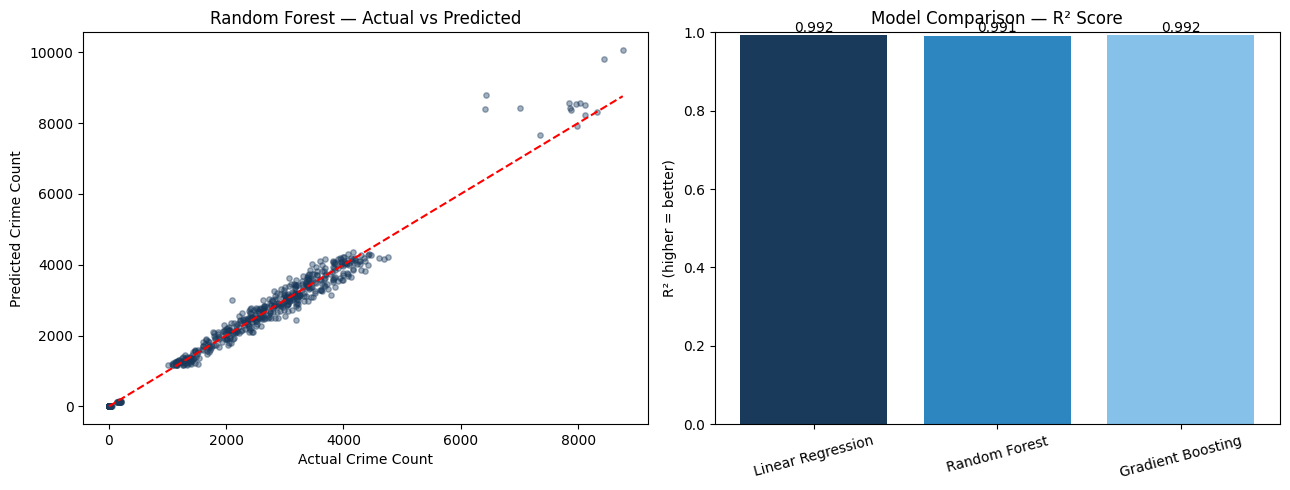

In [6]:
best_model, best_preds = trained['Random Forest']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.4, color=BLUE, s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_title('Random Forest — Actual vs Predicted')
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')

axes[1].bar(results_df['Model'], results_df['R²'], color=[BLUE, '#2E86C1', '#85C1E9'])
axes[1].set_title('Model Comparison — R² Score')
axes[1].set_ylabel('R² (higher = better)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df['R²']):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontsize=10)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/chart_08_ml_results.png', bbox_inches='tight')
plt.show()

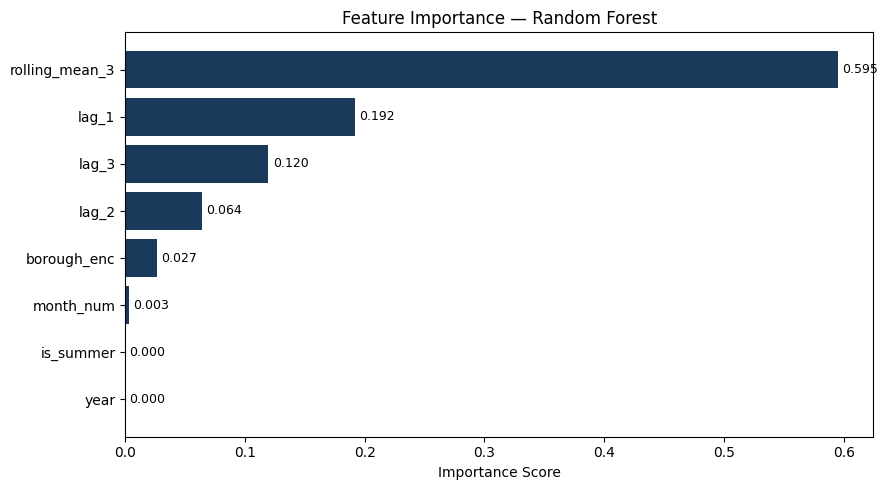

Top feature: rolling_mean_3


In [7]:
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index, importances.values, color=BLUE)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/chart_09_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top feature:', importances.idxmax())

In [8]:
TARGET_BOROUGH = 'Westminster'

bdata = monthly[monthly['borough'] == TARGET_BOROUGH].sort_values(['year','month_num'])

if len(bdata) == 0:
    print(f'Not found. Available boroughs:', monthly['borough'].unique()[:10])
else:
    last = bdata.iloc[-1]
    next_input = pd.DataFrame([{
        'borough_enc':    last['borough_enc'],
        'year':           2026,
        'month_num':      4,
        'is_summer':      0,
        'lag_1':          last['crime_count'],
        'lag_2':          bdata.iloc[-2]['crime_count'],
        'lag_3':          bdata.iloc[-3]['crime_count'],
        'rolling_mean_3': bdata['crime_count'].iloc[-3:].mean()
    }])

    prediction = best_model.predict(next_input)[0]
    print(f'Predicted crimes in {TARGET_BOROUGH} — April 2026: {prediction:,.0f}')
    print(f'Last known actual: {last["crime_count"]:,.0f}')

Predicted crimes in Westminster — April 2026: 8,908
Last known actual: 6,429


In [9]:
print('=== ML RESULTS FOR README ===')
print(results_df.to_string(index=False))
print()
print(f'Top predictive feature: {importances.idxmax()}')

=== ML RESULTS FOR README ===
            Model  MAE  RMSE    R²
Linear Regression 48.6 114.2 0.992
    Random Forest 36.1 121.3 0.991
Gradient Boosting 35.1 111.6 0.992

Top predictive feature: rolling_mean_3
